# Klasifikacija proteinskih sekvenci prema biološkoj funkciji

In [56]:
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## Priprema podataka

### Definisanje klasa

In [26]:
CLASSES = {
    "Hydrolase": "hydrolase.tsv",
    "Transport protein": "transport_protein.tsv",
    "Transcription factor": "transcription_factor.tsv",
    "Receptor": "receptor.tsv",
    "Structural protein": "structural_protein.tsv"
}

### Učitavanje i spajanje TSV fajlova

In [27]:
all_dfs = []
for label, filename in CLASSES.items():
    df = pd.read_csv(f"data\\{filename}", sep="\t")
    df["label"] = label
    print(f"{label}: {len(df)} proteina")
    all_dfs.append(df)

Hydrolase: 2407 proteina
Transport protein: 1242 proteina
Transcription factor: 1418 proteina
Receptor: 1605 proteina
Structural protein: 774 proteina


In [28]:
dataset = pd.concat(all_dfs, ignore_index=True)
os.makedirs("data", exist_ok=True)
dataset.to_csv(os.path.join("data", "uniprot_protein.csv"), index=False)
print(f"CSV fajl 'uniprot_protein.csv' je uspjesno kreiran!")

CSV fajl 'uniprot_protein.csv' je uspjesno kreiran!


## Upoznavanje sa skupom podataka

### Osnovne informacije

In [29]:
print(f"\nUkupan broj proteina: {len(dataset)}")
print(f"Broj klasa: {dataset['label'].nunique()}")
print(f"Dimenzije dataseta: {dataset.shape}")
print(f"\nKolone: {list(dataset.columns)}")


Ukupan broj proteina: 7446
Broj klasa: 5
Dimenzije dataseta: (7446, 5)

Kolone: ['Entry', 'Sequence', 'Protein names', 'Keywords', 'label']


In [30]:
# Prikaz prvih 5 redova dataseta
dataset.head()

,Entry,Sequence,Protein names,Keywords,label
0,A0A1B0GTW7,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,Ciliated left-right organizer metallopeptidase...,Alternative splicing;Disease variant;Glycoprot...,Hydrolase
1,A1A4Y4,MEAMNVEKASADGNLPEVISNIKETLKIVSRTPVNITMAGDSGNGM...,Immunity-related GTPase family M protein (EC 3...,Alternative splicing;Autophagy;Cell membrane;C...,Hydrolase
2,A1KZ92,MEPRLFCWTTLFLLAGWCLPGLPCPSRCLCFKSTVRCMHLMLDHIP...,Probable oxidoreductase PXDNL (EC 1.-.-.-) (Ca...,Alternative splicing;Calcium;Cell membrane;Cyt...,Hydrolase
3,A1Z1Q3,MYPSNKKKKVWREEKERLLKMTLEERRKEYLRDYIPLNSILSWKEE...,ADP-ribose glycohydrolase MACROD2 (MACRO domai...,3D-structure;Alternative splicing;DNA damage;H...,Hydrolase
4,A2A288,MEHPSKMEFFQKLGYDREDVLRVLGKLGEGALVNDVLQELIRTGSR...,Probable ribonuclease ZC3H12D (EC 3.1.-.-) (MC...,Alternative splicing;Chromosomal rearrangement...,Hydrolase


## Predprocesiranje podataka

### Uklanjanje duplikata

In [31]:
duplicates = dataset['Sequence'].duplicated().sum()
print(f"Broj duplikata: {duplicates}")

dataset = dataset.drop_duplicates(subset="Sequence").reset_index(drop=True)
print(f"Ukupno proteina nakon uklanjanja duplikata: {len(dataset)}")

Broj duplikata: 402
Ukupno proteina nakon uklanjanja duplikata: 7044


In [32]:
# Distribucija klasa nakon uklanjanja duplikata
print(dataset['label'].value_counts())

label
Hydrolase               2403
Transcription factor    1405
Receptor                1386
Transport protein       1138
Structural protein       712
Name: count, dtype: int64


### Uklanjanje nedostajućih vrijednosti

In [33]:
# Redovi sa praznom sekvencom
print(f"Broj redova sa praznom sekvencom: {dataset['Sequence'].isna().sum()}")

Broj redova sa praznom sekvencom: 0


### Uklanjanje sekvenci sa nestandardnim aminokiselinama

Proteinske sekvence se predstavljaju pomoću 20 standardnih aminokiselina (A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y).

Sekvence koje sadrže nestandardne oznake (X, B, Z, U, O) su uklonjene iz dataseta jer predstavljaju neodređene ili modifikovane aminokiseline.

In [34]:
def valid_sequence(seq):
    valid_aa = set("ACDEFGHIKLMNPQRSTVWY")
    seq = str(seq).upper().strip()

    unvalid = [aa for aa in seq if aa not in valid_aa]
    if unvalid:
        print(f"Nevalidni karakteri: {set(unvalid)}")
        return None
    
    if len(seq) < 10:
        print(f"Prekratka sekvenca: {len(seq)}")
        return None
    
    return seq

dataset['Sequence'] = dataset['Sequence'].apply(valid_sequence)

total_before = len(dataset)
dataset = dataset.dropna(subset=['Sequence'])
total_after = len(dataset)

print(f"Prije odbacivanja: {total_before} proteina")
print(f"Nakon odbacivanja: {total_after} proteina")

Nevalidni karakteri: {'U'}
Prije odbacivanja: 7044 proteina
Nakon odbacivanja: 7043 proteina


## Eksploratorna analiza podataka (EDA)

### Statistički pregled dužina sekvenci po klasi

U ovom koraku analiziramo distribuciju dužina proteinskih sekvenci unutar svake funkcionalne klase. Različite funkcije proteina često zahtijevaju različite strukturne kompleksnosti, što se odražava na broj aminokiselina u sekvencama.

In [55]:
dataset["seq_length"] = dataset["Sequence"].str.len()

stats_df = dataset.groupby("label")["seq_length"].describe().round(1)
print(stats_df)

                       count   mean     std   min    25%    50%    75%  \
label                                                                    
Hydrolase             2403.0  637.5   502.8  51.0  315.0  498.0  804.5   
Receptor              1385.0  512.4   435.8  85.0  312.0  345.0  520.0   
Structural protein     712.0  814.5  1661.2  25.0  175.0  398.0  849.2   
Transcription factor  1405.0  540.7   331.4  34.0  354.0  481.0  627.0   
Transport protein     1138.0  588.7   524.0  55.0  315.0  484.0  676.8   

                          max  
label                          
Hydrolase              6306.0  
Receptor               5079.0  
Structural protein    34350.0  
Transcription factor   3953.0  
Transport protein      5038.0  


#### Histogram raspodjele po klasama

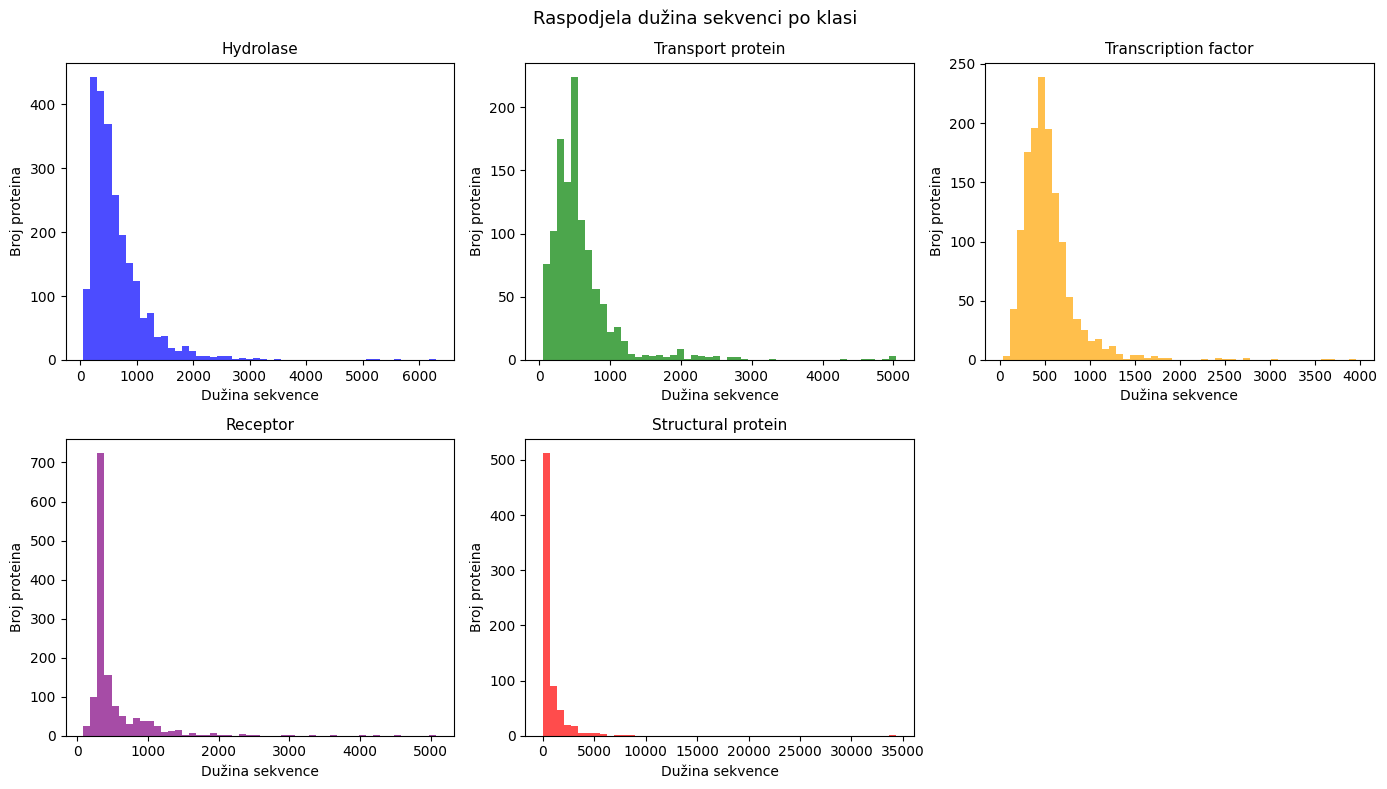

In [146]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

classes = dataset['label'].unique()
colors = ['blue', 'green', 'orange', 'purple', 'red']

for i, (cls, color) in enumerate(zip(classes, colors)):
    subset = dataset[dataset['label'] == cls]['seq_length']
    axes[i].hist(subset, bins=50, color=color, alpha=0.7)
    axes[i].set_title(cls, fontsize=11)
    axes[i].set_xlabel("Dužina sekvence")
    axes[i].set_ylabel("Broj proteina")

axes[5].set_visible(False)
plt.suptitle("Raspodjela dužina sekvenci po klasi", fontsize=13)
plt.tight_layout()
plt.show()

#### Box plot distribucije dužina

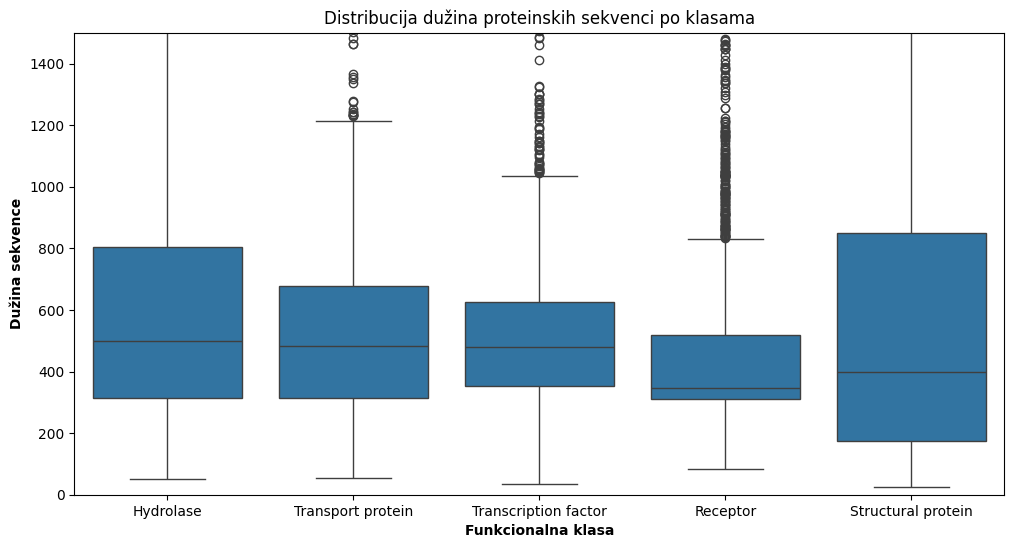

In [127]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="label", y="seq_length", data=dataset)
plt.title("Distribucija dužina proteinskih sekvenci po klasama")
plt.xlabel("Funkcionalna klasa", fontweight="bold")
plt.ylabel("Dužina sekvence", fontweight="bold")
plt.ylim(0, 1500)
plt.show()

### Analiza sastava aminokiselina po klasi

Cilj ove analize je utvrditi da li određene funckionalne grupe proteina favorizuju specifične aminokiseline. Razlike u frekvenciji aminokiselina direktno utiču na fizičko-hemijska svojstva proteina i njegovu biološku ulogu.

In [54]:
aminoacids = list("ACDEFGHIKLMNPQRSTVWY")

freq_matrix = {}
for label, group in dataset.groupby("label"):
    all = "".join(group['Sequence'].values)
    total = len(all)
    freq_matrix[label] = {aa: round(all.count(aa) / total*100, 2) for aa in aminoacids}

freq_df = pd.DataFrame(freq_matrix).T
print(freq_df)

                         A     C     D     E     F     G     H     I     K  \
Hydrolase             6.81  2.15  5.15  6.94  3.91  6.54  2.60  4.84  5.81   
Receptor              6.88  3.26  3.90  4.68  4.83  6.38  2.51  5.48  3.89   
Structural protein    7.16  2.31  4.89  7.47  2.75  8.44  2.19  4.05  5.94   
Transcription factor  6.99  3.21  3.84  7.24  3.38  7.14  4.15  3.27  6.57   
Transport protein     7.39  2.09  4.12  5.66  5.18  6.92  2.17  5.65  4.52   

                          L     M     N     P     Q     R     S     T     V  \
Hydrolase              9.98  2.20  3.83  5.59  4.59  5.57  7.55  5.29  6.32   
Receptor              11.55  2.41  3.88  5.74  3.63  4.85  8.29  5.96  7.08   
Structural protein     8.36  1.79  3.26  6.98  4.89  5.54  8.31  6.29  6.05   
Transcription factor   7.94  1.84  3.35  7.58  5.27  5.66  9.37  5.36  4.48   
Transport protein     11.52  2.61  3.51  5.20  3.68  5.02  7.65  5.39  6.95   

                         W     Y  
Hydrolase            

#### Heatmapa frekvencije aminokiselina po klasama

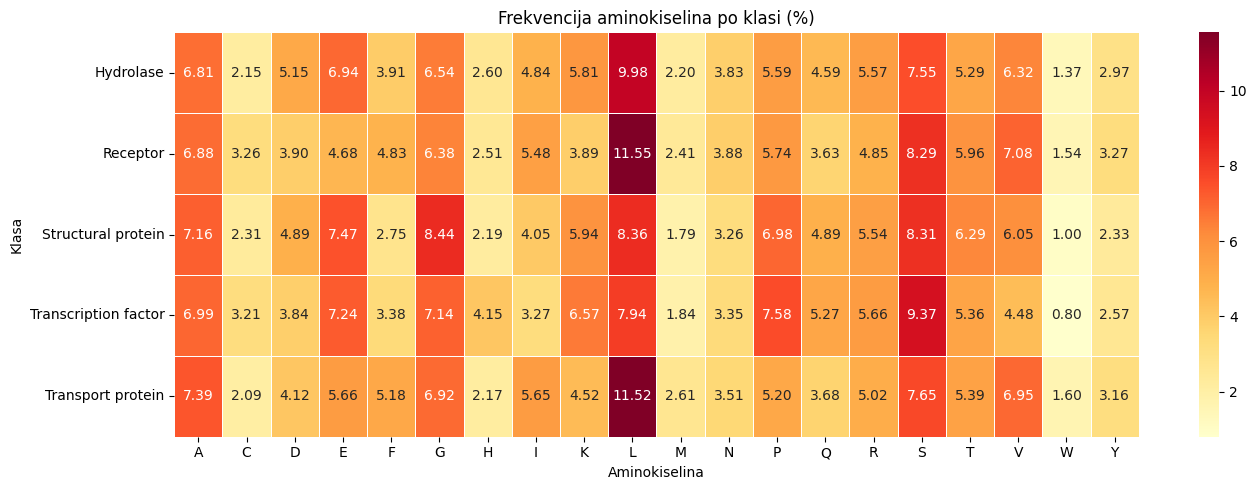

In [ ]:
plt.figure(figsize=(14, 5))
sns.heatmap(freq_df, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Frekvencija aminokiselina po klasi (%)")
plt.xlabel("Aminokiselina")
plt.ylabel("Klasa")
plt.tight_layout()
plt.show()

### Vizualizacija distribucije klasa

U cilju boljeg razumijevanja strukture dataseta, prikazana je distribucija proteina po klasama. Analiza distribucije omogućava uočavanja neuravnoteženosti između klasa.

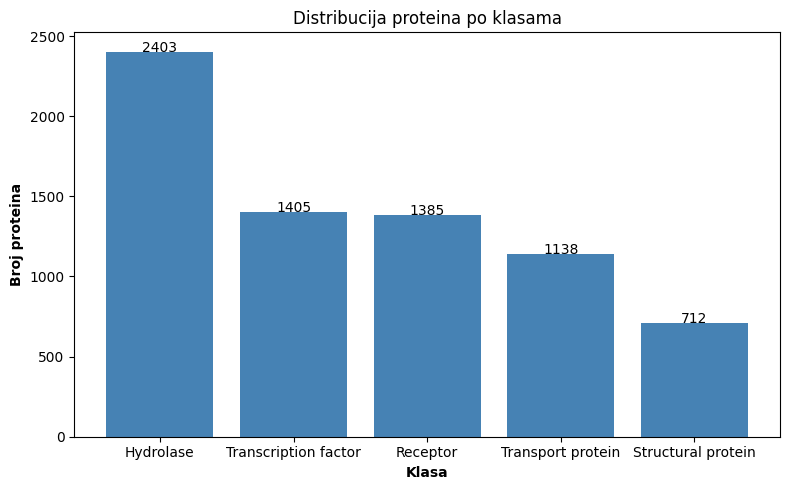

In [72]:
class_counts = dataset["label"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color="steelblue")
plt.title("Distribucija proteina po klasama")
plt.xlabel("Klasa", fontweight="bold")
plt.ylabel("Broj proteina", fontweight="bold")

for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha="center")

plt.tight_layout()
plt.show()

## Primjena metoda mašinskog učenja

### Podjela skupa na ulazne i ciljne atribute

In [84]:
# Priprema x i y
x = dataset['Sequence'].values
y = dataset['label'].values

### Kodiranje ciljne varijable (Label Encoding)

In [85]:
le = LabelEncoder()
y = le.fit_transform(y)

print("Mapiranje klasa:")
for num, label in enumerate(le.classes_):
    print(f"{num} -> {label}")

Mapiranje klasa:
0 -> Hydrolase
1 -> Receptor
2 -> Structural protein
3 -> Transcription factor
4 -> Transport protein


### Podjela na skup za treniranje i testiranje

In [86]:
# Train/Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train skup:  {len(x_train)} proteina (80%)")
print(f"Test skup:  {len(x_test)} proteina (20%)")

Train skup:  5634 proteina (80%)
Test skup:  1409 proteina (20%)


### TF-IDF (Term Frequency-Inverse Document Frequency)

Transformišemo proteinske sekvence u numeričke vektore koristeći **TF-IDF** statistiku. TF-IDF penalizuje trigrame koji se prečesto pojavljuju u svim klasama, a naglašava one koji su jedinstveni za specifične funkcionalne grupe.

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [114]:
# Kreiranje trigrama
def split_sequence(seq, n=3):
    return " ".join([seq[i:i+n] for i in range(len(seq)-n+1)])

x_train_split = pd.Series(x_train).apply(split_sequence)
x_test_split = pd.Series(x_test).apply(split_sequence)

In [115]:
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1,1), max_features=15000)
x_train_tfidf = tfidf.fit_transform(x_train_split)
x_test_tfidf = tfidf.fit_transform(x_test_split)

print(f"Dimenzije train matrice: {x_train_tfidf.shape}")
print(f"Dimenzije test matrice: {x_test_tfidf.shape}")

Dimenzije train matrice: (5634, 8000)
Dimenzije test matrice: (1409, 8000)


In [116]:
# Prvih 20 trigrama (features)
print(tfidf.get_feature_names_out()[:20])

['aaa' 'aac' 'aad' 'aae' 'aaf' 'aag' 'aah' 'aai' 'aak' 'aal' 'aam' 'aan'
 'aap' 'aaq' 'aar' 'aas' 'aat' 'aav' 'aaw' 'aay']


### Naive Bayes (Complement NB) - baseline metoda

In [117]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score


In [118]:
nb_model = ComplementNB()
nb_model.fit(x_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [ ]:
### Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(x_train_tfidf, y_train)

y_pred_rf = rf_model.predict(x_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy: 0.6835

Classification Report:
                      precision    recall  f1-score   support

           Hydrolase       0.54      0.96      0.69       481
            Receptor       0.92      0.56      0.69       277
  Structural protein       0.82      0.39      0.53       142
Transcription factor       0.92      0.72      0.81       281
   Transport protein       0.87      0.40      0.55       228

            accuracy                           0.68      1409
           macro avg       0.81      0.60      0.65      1409
        weighted avg       0.77      0.68      0.68      1409



In [105]:
### Support Vector Machine (SVM)

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    class_weight="balanced",
    max_iter=2000
)

svm_model.fit(x_train_tfidf, y_train)

y_pred_svm = svm_model.predict(x_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Accuracy: 0.8070

Classification Report:
                      precision    recall  f1-score   support

           Hydrolase       0.81      0.85      0.83       481
            Receptor       0.84      0.82      0.83       277
  Structural protein       0.66      0.61      0.64       142
Transcription factor       0.90      0.92      0.91       281
   Transport protein       0.74      0.70      0.72       228

            accuracy                           0.81      1409
           macro avg       0.79      0.78      0.78      1409
        weighted avg       0.80      0.81      0.81      1409



## Definisanje ML modela

- **SVM** (Support Vector Machine) 
- **Random Forest** 
- **Naive Bayes** 

### Support Vector Machine (SVM)

In [30]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [37]:
# Defnisanje SVM Pipeline
svm_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(**cv_params)),
    ('classifier', LinearSVC(C=1.0, class_weight='balanced', random_state=42))
])

svm_pipeline.fit(x_train, y_train)

C:\Users\EC\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(**cv_params)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

rf_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### Naive Bayes

In [20]:
from sklearn.naive_bayes import MultinomialNB
from imblearn.under_sampling import RandomUnderSampler

In [21]:
rus = RandomUnderSampler(random_state=42)
x_train_rus, y_train_rus = rus.fit_resample(x_train.reshape(-1, 1), y_train)
x_train_rus = x_train_rus.reshape(-1)

In [48]:
nb_pipeline = Pipeline([
    ('vecortizer', CountVectorizer(**cv_params)),
    ('classifier', MultinomialNB())
])

nb_pipeline.fit(x_train_rus, y_train_rus)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vecortizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### Evaluacija

In [97]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

def report(model, x, y, text):
    print(text)
    y_pred = model.predict(x)

    print("---------------------------------------------------------------------------------")
    print("Classification report:")
    print("---------------------------------------------------------------------------------")
    print(classification_report(y, y_pred))
    print("---------------------------------------------------------------------------------")
    print("Confusion matrix:")
    print("---------------------------------------------------------------------------------")
    print(pd.DataFrame(confusion_matrix(y, y_pred), columns=le.classes_, index=le.classes_))
    print("---------------------------------------------------------------------------------")
 

In [42]:
report(svm_pipeline, x_train, y_train, "SVM - Trening skup")

SVM - Trening skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1925
           1       0.98      0.91      0.94      1283
           2       0.98      0.91      0.94       618
           3       0.98      0.98      0.98      1134
           4       0.90      0.97      0.93       994

    accuracy                           0.95      5954
   macro avg       0.96      0.95      0.95      5954
weighted avg       0.95      0.95      0.95      5954

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                  1877         3                 

In [43]:
report(svm_pipeline, x_test, y_test, "SVM - Test skup")

SVM - Test skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.70      0.73      0.71       482
           1       0.73      0.68      0.71       321
           2       0.66      0.55      0.60       155
           3       0.84      0.84      0.84       283
           4       0.53      0.59      0.56       248

    accuracy                           0.70      1489
   macro avg       0.69      0.68      0.68      1489
weighted avg       0.70      0.70      0.70      1489

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   350        25                  26

In [45]:
report(rf_pipeline, x_train, y_train, "Random Forest - Trening skup")

Random Forest - Trening skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1925
           1       0.96      0.93      0.94      1283
           2       0.94      0.99      0.96       618
           3       0.98      0.98      0.98      1134
           4       0.89      0.98      0.93       994

    accuracy                           0.96      5954
   macro avg       0.95      0.96      0.96      5954
weighted avg       0.96      0.96      0.96      5954

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                  1815        21       

In [46]:
report(rf_pipeline, x_test, y_test, "Random Forest - Test skup")

Random Forest - Test skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.55      0.86      0.67       482
           1       0.72      0.52      0.61       321
           2       0.73      0.49      0.59       155
           3       0.88      0.76      0.82       283
           4       0.63      0.38      0.47       248

    accuracy                           0.65      1489
   macro avg       0.70      0.60      0.63      1489
weighted avg       0.68      0.65      0.64      1489

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   415        21          

In [ ]:
report(nb_pipeline, x_train_rus, y_train_rus, "Naive Bayes - Trening skup")

Naibe Bayes - Trening skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.51      0.78      0.61       618
           1       0.82      0.74      0.77       618
           2       0.61      0.51      0.56       618
           3       0.96      0.71      0.81       618
           4       0.77      0.77      0.77       618

    accuracy                           0.70      3090
   macro avg       0.73      0.70      0.70      3090
weighted avg       0.73      0.70      0.70      3090

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   481        41         

In [50]:
report(nb_pipeline, x_test, y_test, "Naive Bayes - Test skup")

Naive Bayes - Test skup
---------------------------------------------------------------------------------
Classification report:
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.66      0.71      0.68       482
           1       0.75      0.65      0.70       321
           2       0.36      0.52      0.43       155
           3       0.97      0.65      0.78       283
           4       0.60      0.69      0.64       248

    accuracy                           0.66      1489
   macro avg       0.67      0.64      0.64      1489
weighted avg       0.70      0.66      0.67      1489

---------------------------------------------------------------------------------
Confusion matrix:
---------------------------------------------------------------------------------
                      Hydrolase  Receptor  Structural protein  \
Hydrolase                   341        34            